In [1]:
import socket
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import psutil
#import pygetdata as gd
import os
import time
import struct
import sys
#import queen_tui

In [2]:
sys.path.append('/usr/lib/python3/')

In [3]:
UDP_IP = "192.168.3.40"

UDP_PORT = 4096

In [4]:
sock = socket.socket(socket.AF_INET, # Internet

           socket.SOCK_DGRAM) # UDP

sock.bind((UDP_IP, UDP_PORT)) 

In [33]:
def capturePacket(byteshift=-1):
    """
    Q - Remove byte rolling and conversion to separate function?
    """

    data = sock.recv(9000) # buffer size is 1024 bytes

    data = bytearray(data)

    data = np.roll(data,byteshift)

    return np.frombuffer(data, dtype="<i").astype("float")


def getNpackets(N,byteshift=-1):

    packets = capturePacket(byteshift)

    for p in range(N):

        newPacket = capturePacket(byteshift)

        packets = np.vstack([packets,newPacket])

    return packets


def getNpackets_2(N,byteshift=-1):
    
    return np.array([capturePacket(byteshift) for p in range(N)])

def livePlot():
    from matplotlib import pyplot as plt
    from IPython.display import clear_output
    import numpy as np
    plt.figure()
    for i in range(10):
        clear_output(wait=True)
        y=getNpackets_2(48)
        print (i)
        print (y.shape)
        #for j in range(1):
        #plt.plot(range(i*48,(i+1)*48),y[:, 16+1*2]**2.0+y[:, 17+1*2]**2.0)
        plt.plot(y[:, 16+1*2]**2.0+y[:, 17+1*2]**2.0)
        plt.show()

        
        
def saveDirfileIQ(time_interval):
    data_path = "./" #self.gc[np.where(self.gc == 'DIRFILE_SAVEPATH')[0][0]][1]
    sub_folder = input("Insert subfolder name (e.g. single_tone): ")
    data_rate = 512e6/2**20
    Npackets = np.ceil(time_interval * data_rate)
    Npackets = int(np.ceil(Npackets))
    save_path = os.path.join(data_path, sub_folder)
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    filename = save_path + '/' + \
               str(int(time.time())) + '-' + time.strftime('%b-%d-%Y-%H-%M-%S') + '.dir'
    # make the dirfile
    d = gd.dirfile(filename,gd.CREAT|gd.RDWR|gd.UNENCODED)
    d.add_spec('I RAW FLOAT32 1')
    d.add_spec('Q RAW FLOAT32 1')
    d.close()
    d = gd.dirfile(filename,gd.RDWR|gd.UNENCODED)
    i_file = open(filename + "/I", "ab")
    q_file = open(filename + "/Q", "ab")
    count = 0
    while count < Npackets:
        p = capturePacket()
        I, Q = p[16], p[17]
        i_file.write(struct.pack('<f', I))
        q_file.write(struct.pack('<f', Q))
        i_file.flush()
        q_file.flush()
        d.flush()
        count += 1
    i_file.close()
    q_file.close()
    d.close()
    return





In [34]:
t_sec = 2
packetrate = 512e6/(2.0**20)
N_packet = int(packetrate*t_sec)
#p9 = getNpackets_2(N_packet)
p9 = getNpackets(N_packet)
print(len(p9[0]))

2052


In [35]:
t_sec = 10
packetrate = 512e6/(2.0**20)
N_packet = int(packetrate*t_sec)
p9 = getNpackets_2(N_packet)

# s21_targ_1_1_20221028T004116Z.npy
# 5 original
# 6 off resonance 
# 7 on again
# 8 first tone power increased by 3dB
# s21_targ_1_1_20221027T235218Z.npy
# 9 set frequency for the first tone manually
# power increased by 3dB
# s21_targ_1_1_20221028T004116Z.npy


# for i in range(4):
#     print("Hello")
#     p=getNpackets_2(N_packet)
#     np.save('/home/rfsoc/rfsoc_result/Steve/230817/230817_timestream_104mK_15_mins_batch_' + str(1+i)+'.npy',p)
# np.save('/home/rfsoc/rfsoc_result/Steve/230906/230906_timestream_100mK_10s_-32dB_atten_6p53_K_coldload_power_increase_2.npy',p5)
# np.save('/home/rfsoc/rfsoc_result/Steve/230906/230906_timestream_100mK_10s_-32dB_atten_6p53_K_coldload_power_increase_2.npy',p6)

In [40]:
np.save('/home/rfsoc/rfsoc_result/Steve/230906/230906_timestream_100mK_10s_-32dB_atten_6p53_K_coldload_power_increase_2_off_res.npy',p6)
np.save('/home/rfsoc/rfsoc_result/Steve/230906/230906_timestream_100mK_10s_-32dB_atten_6p53_K_coldload_power_increase_2_on_again.npy',p7)
np.save('/home/rfsoc/rfsoc_result/Steve/230906/230906_timestream_100mK_10s_-32dB_atten_6p53_K_coldload_power_increase_2_power_increase_3db.npy',p8)
np.save('/home/rfsoc/rfsoc_result/Steve/230906/230906_timestream_100mK_10s_-32dB_atten_6p53_K_coldload_power_increase_2_set_f0_again.npy',p9)
# np.save('/home/rfsoc/rfsoc_result/Steve/230906/230906_timestream_100mK_10s_-32dB_atten_6p53_K_coldload_power_increase_2_off_res.npy',p10)

[[-6.41200000e+03 -7.43800000e+03 -6.41200000e+03 ...  0.00000000e+00
   1.97971149e+09  3.27427000e+05]
 [-6.15300000e+03 -7.75300000e+03 -6.15300000e+03 ...  0.00000000e+00
   1.97971149e+09  3.92963000e+05]
 [-6.09900000e+03 -8.08500000e+03 -6.09900000e+03 ...  0.00000000e+00
   1.97971149e+09  4.58499000e+05]
 ...
 [-6.03300000e+03 -7.32400000e+03 -6.03300000e+03 ...  0.00000000e+00
   1.97971149e+09  1.58951000e+06]
 [-6.30300000e+03 -7.70700000e+03 -6.30300000e+03 ...  0.00000000e+00
   1.97971149e+09  8.40525400e+06]
 [-6.39700000e+03 -7.82600000e+03 -6.39700000e+03 ...  0.00000000e+00
   1.97971149e+09  8.47079000e+06]]


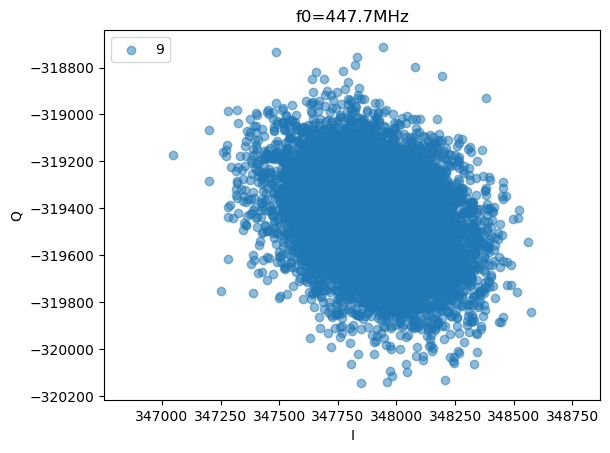

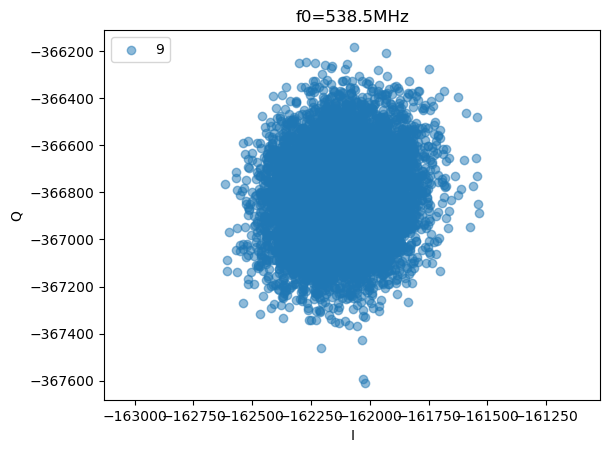

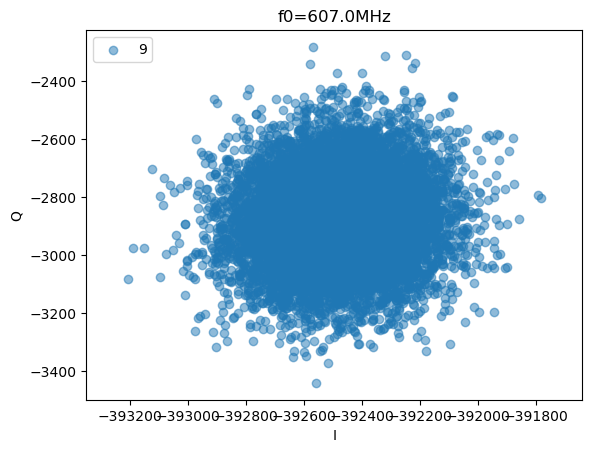

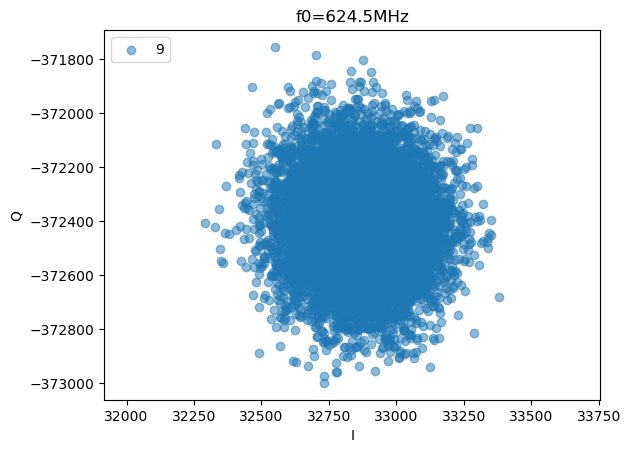

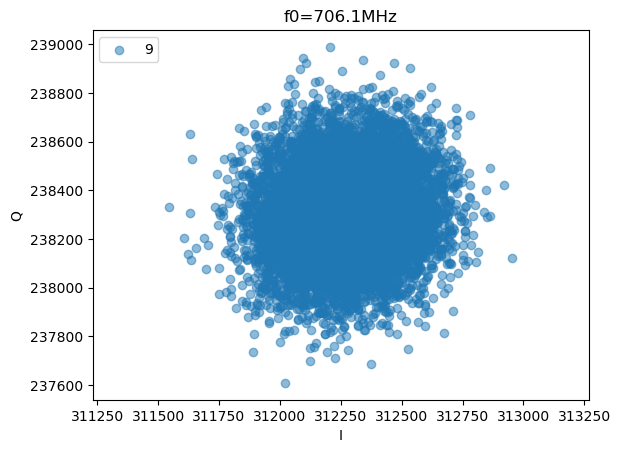

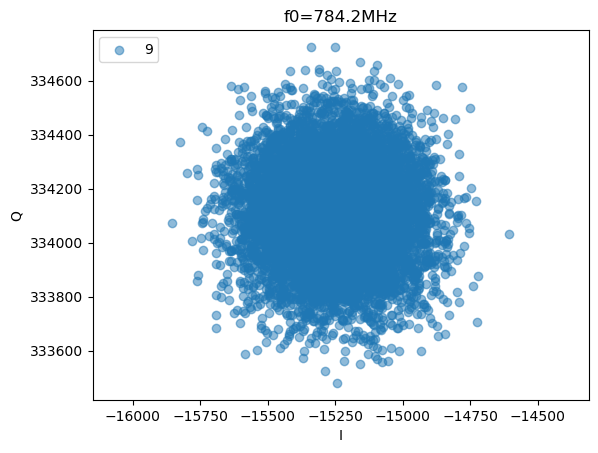

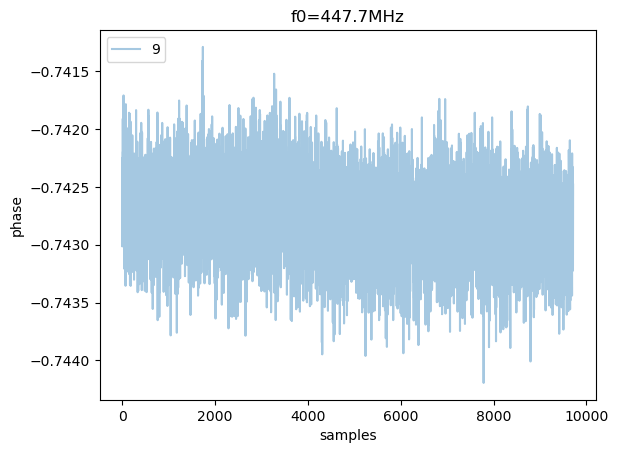

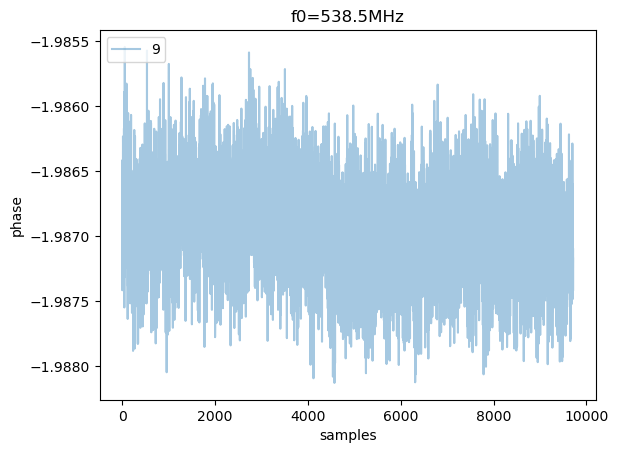

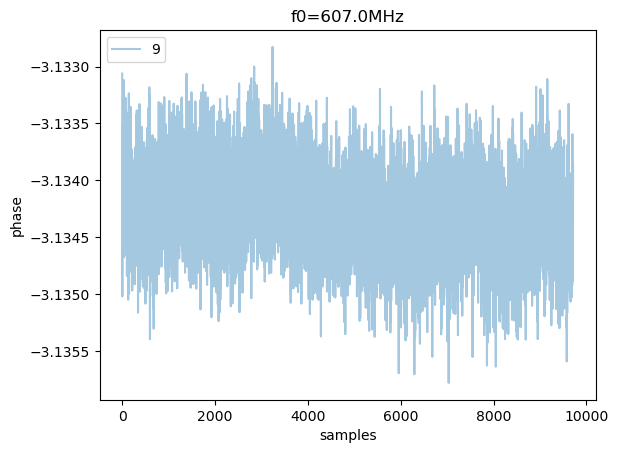

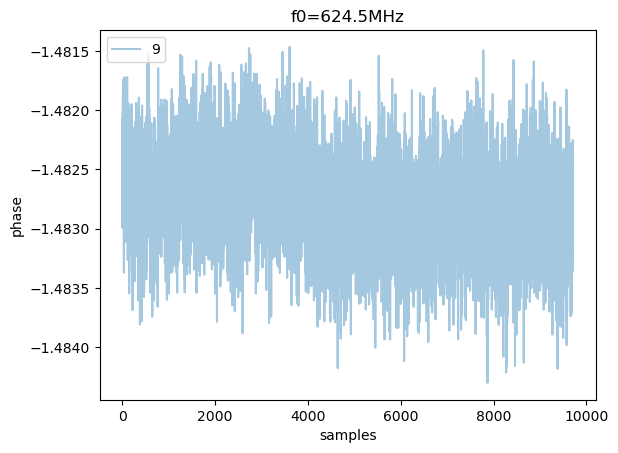

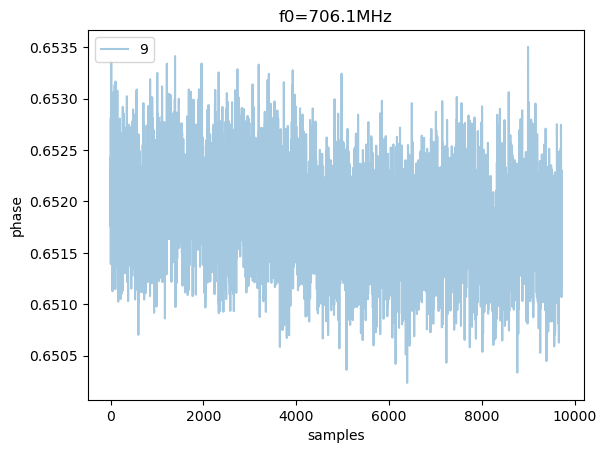

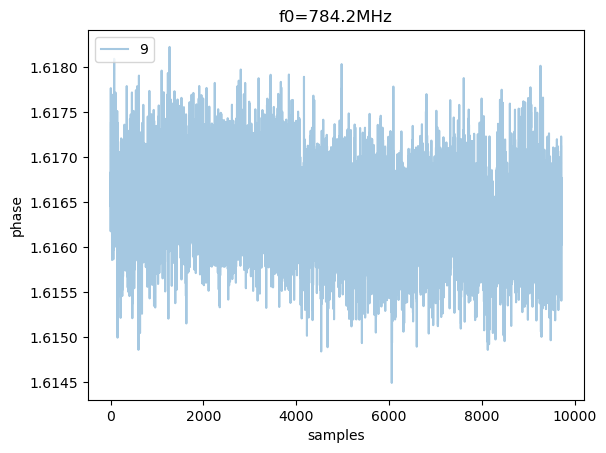

In [39]:
t_sec = 20
packetrate = 512e6/(2.0**20)
N_packet = int(packetrate*t_sec)
#p9 = getNpackets_2(N_packet)
p9 = getNpackets(N_packet)
print(p9)

f_res = [447.66e6, 538.55e6,607.02e6,624.54e6,706.12e6,784.18e6]

for i in range(6):
    plt.figure()
    plt.scatter(p9[:,16+2*i][50:], p9[:,16+2*i+1][50:],alpha=0.5,label='9')
    plt.title('f0=%.1fMHz'%(f_res[i]/1e6))
    plt.axis('equal')
    plt.xlabel('I')
    plt.ylabel('Q')
    plt.legend(loc=2)
    plt.show()

for i in range(6):
    plt.figure()
    plt.plot(np.arctan2(p9[:,16+2*i+1][50:],p9[:,16+2*i][50:]),alpha=0.4,label='9')
    plt.title('f0=%.1fMHz'%(f_res[i]/1e6))
#     plt.axis('equal')
    plt.xlabel('samples')
    plt.ylabel('phase')
    plt.legend(loc=2)
    plt.show()

In [21]:

for i in range(5):
    plt.figure()
    plt.scatter(p5[:,16+2*i][50:], p5[:,16+2*i+1][50:],alpha=0.5,label='5')
    plt.scatter(p6[:,16+2*i][50:], p6[:,16+2*i+1][50:],alpha=0.4,label='6')
    plt.scatter(p7[:,16+2*i][50:], p7[:,16+2*i+1][50:],alpha=0.3,label='7')
    plt.scatter(p8[:,16+2*i][50:], p8[:,16+2*i+1][50:],alpha=0.3,label='8')
    plt.title('f0=%.1fMHz'%(f_res[i]/1e6))
    plt.axis('equal')
    plt.xlabel('I')
    plt.ylabel('Q')
    plt.legend(loc=2)
    plt.show()

for i in range(5):
    plt.figure()
    plt.plot(np.arctan2(p5[:,16+2*i+1][50:],p5[:,16+2*i][50:]),alpha=0.5,label='5')
    plt.plot(np.arctan2(p6[:,16+2*i+1][50:],p6[:,16+2*i][50:]),alpha=0.4,label='6')
    plt.plot(np.arctan2(p7[:,16+2*i+1][50:],p7[:,16+2*i][50:]),alpha=0.4,label='7')
    plt.plot(np.arctan2(p8[:,16+2*i+1][50:],p8[:,16+2*i][50:]),alpha=0.4,label='8')
    plt.title('f0=%.1fMHz'%(f_res[i]/1e6))
#     plt.axis('equal')
    plt.xlabel('samples')
    plt.ylabel('phase')
    plt.legend(loc=2)
    plt.show()


NameError: name 'p5' is not defined

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_439429/1289889023.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


<IPython.core.display.Javascript object>


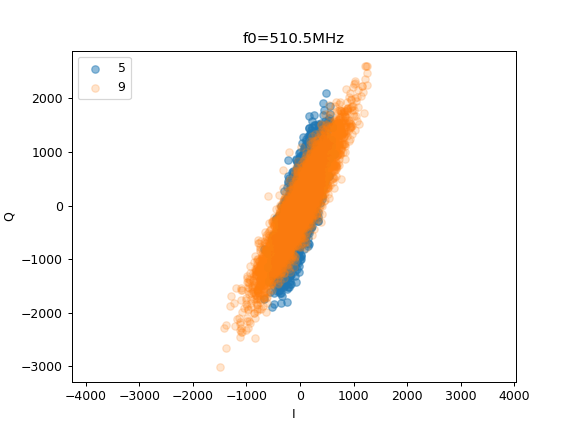

<IPython.core.display.Javascript object>


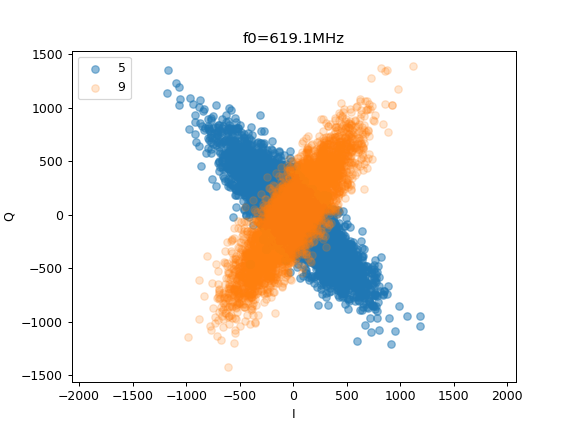

<IPython.core.display.Javascript object>


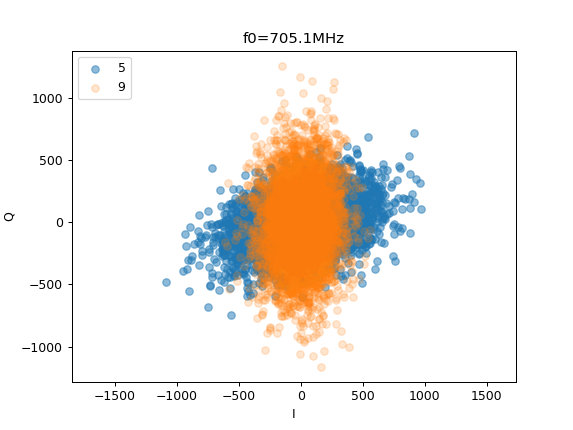

<IPython.core.display.Javascript object>


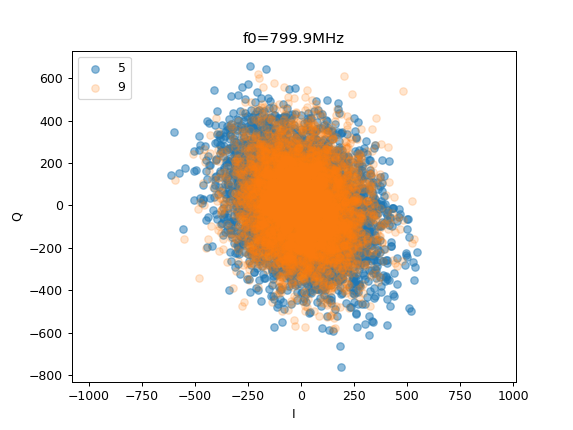

<IPython.core.display.Javascript object>


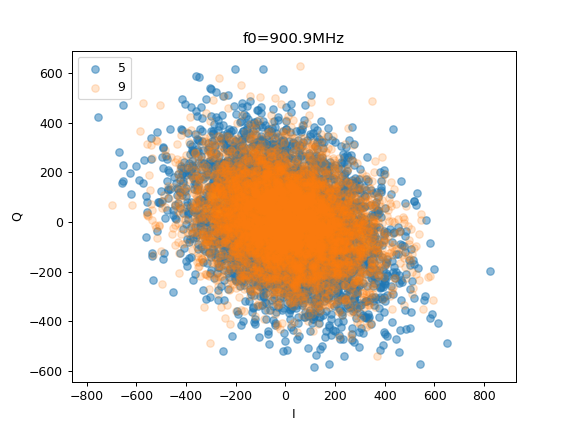

In [39]:
for i in range(5):
    plt.figure()
    plt.scatter(p5[:,16+2*i][50:]-np.mean(p5[:,16+2*i][50:]), p5[:,16+2*i+1][50:]-np.mean(p5[:,16+2*i+1][50:]),alpha=0.5,label='5')
#     plt.scatter(p6[:,16+2*i][50:]-np.mean(p6[:,16+2*i][50:]), p6[:,16+2*i+1][50:]-np.mean(p6[:,16+2*i+1][50:]),alpha=0.4,label='6')
#     plt.scatter(p7[:,16+2*i][50:]-np.mean(p7[:,16+2*i][50:]), p7[:,16+2*i+1][50:]-np.mean(p7[:,16+2*i+1][50:]),alpha=0.3,label='7')
#     plt.scatter(p8[:,16+2*i][50:]-np.mean(p8[:,16+2*i][50:]), p8[:,16+2*i+1][50:]-np.mean(p8[:,16+2*i+1][50:]),alpha=0.2,label='8')
    plt.scatter(p9[:,16+2*i][50:]-np.mean(p9[:,16+2*i][50:]), p9[:,16+2*i+1][50:]-np.mean(p9[:,16+2*i+1][50:]),alpha=0.2,label='9')
    plt.title('f0=%.1fMHz'%(f_res[i]/1e6))
    plt.axis('equal')
    plt.xlabel('I')
    plt.ylabel('Q')
    plt.legend(loc=2)
    plt.show()

<IPython.core.display.Javascript object>


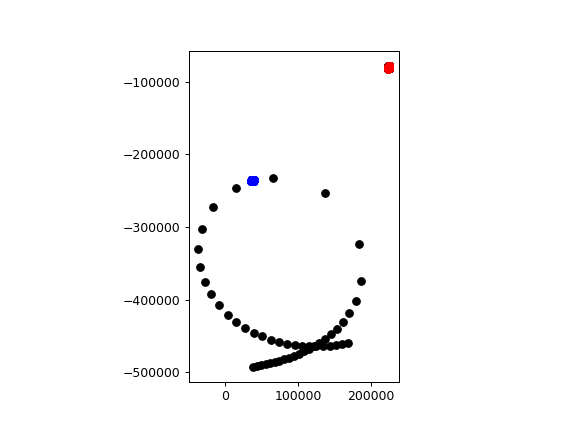

<IPython.core.display.Javascript object>


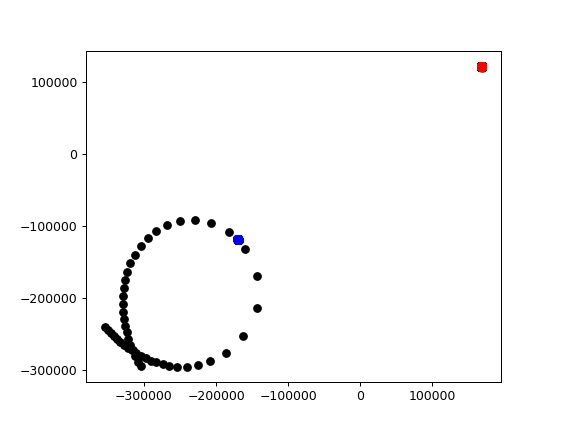

<IPython.core.display.Javascript object>


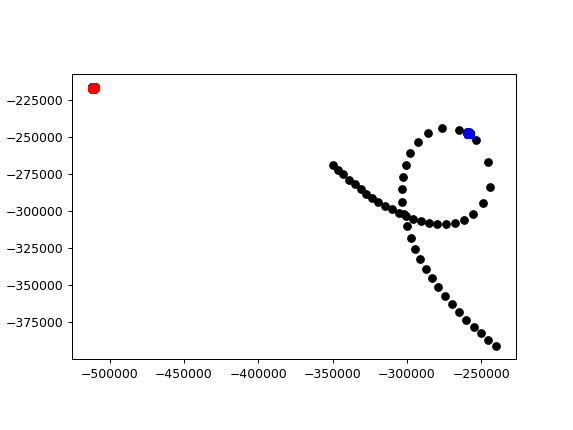

<IPython.core.display.Javascript object>


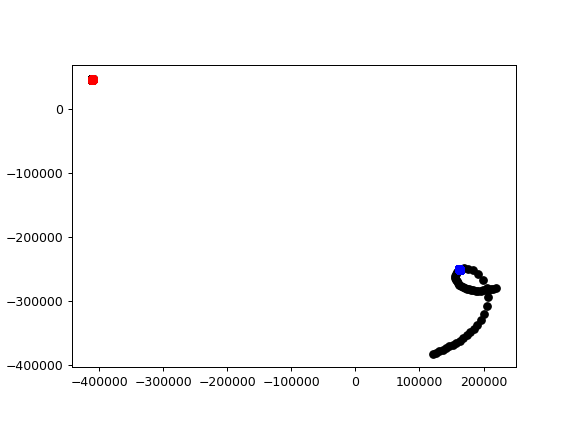

<IPython.core.display.Javascript object>


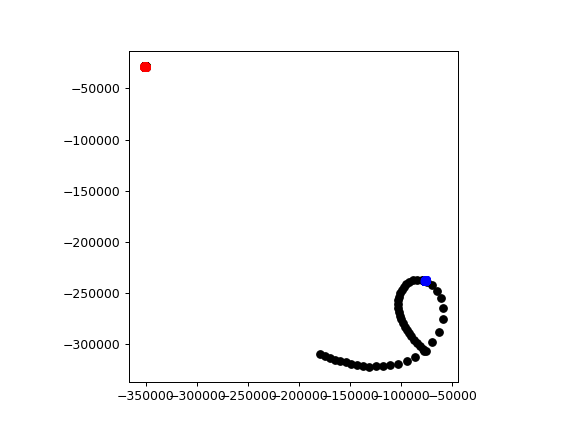

<IPython.core.display.Javascript object>


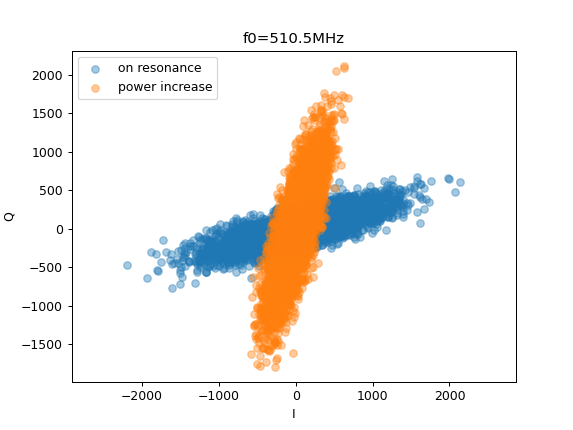

<IPython.core.display.Javascript object>


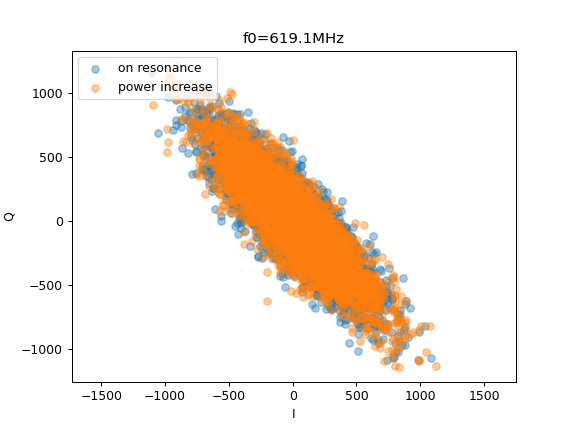

<IPython.core.display.Javascript object>


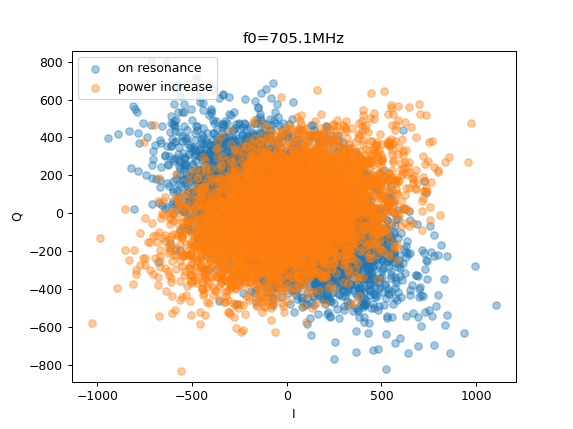

<IPython.core.display.Javascript object>


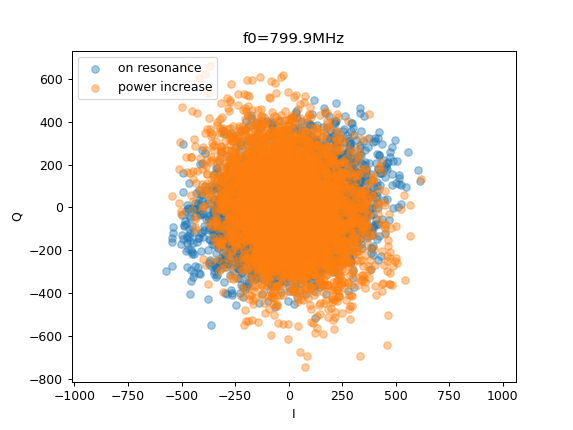

<IPython.core.display.Javascript object>


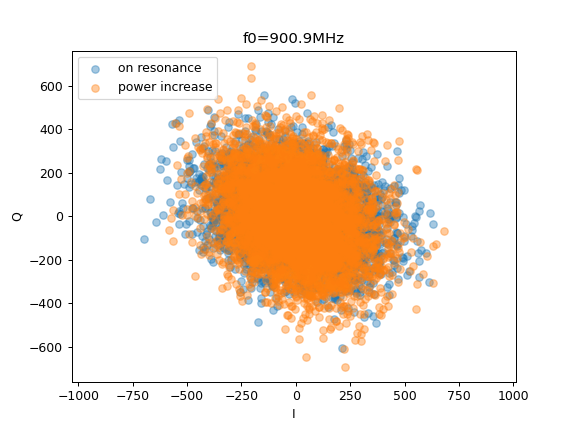

In [31]:
%matplotlib notebook
targ = np.load('/home/rfsoc/CCATpHive/tmp/s21_targ_1_1_20221027T232454Z.npy')
f_res = np.load('/home/rfsoc/CCATpHive/tmp/f_res_targ_1_1_20221027T232225Z.npy', allow_pickle = True)
# s21_46 = np.load('/home/rfsoc/rfsoc_result/Steve/230817/230817_timestream_58mK_30s_-46dBm.npy')
# s21_52 = np.load('/home/rfsoc/rfsoc_result/Steve/230817/230817_timestream_58mK_30s_-52dBm.npy')
# s21_52_shifted = np.load('/home/rfsoc/rfsoc_result/Steve/230817/230817_timestream_58mK_30s_-52dBm_2MHz.npy')

f_max = 1e5

# plt.scatter(np.real(targ[1]),np.imag(targ[1]))
# i = 1

# plt.scatter(p[:,16+2*i], p[:,16+2*i+1],alpha=0.6)
# plt.show()

for i in range(5):
    plt.figure()
    #plt.scatter(np.abs(targ_46[0]), np.angle(np.imag(targ_46[1])))
    #plt.scatter(np.ones(len(s21_46[:, 16+2*i]))*f_46[i], np.angle(s21_46[:, 16+2*i] + 1j*s21_46[:, 16+2*i+1]))
#     plt.scatter(np.real(targ[1][np.where(np.real(np.abs(targ[0]-f_res[i])) <= f_max)]), np.imag(targ[1][np.where(np.real(np.abs(targ[0]-f_res[i])) <= f_max)]))
    plt.scatter(np.real(targ[1][np.where(np.real(np.abs(targ[0]-f_res[i])) <= f_max)]), np.imag(targ[1][np.where(np.real(np.abs(targ[0]-f_res[i])) <= f_max)]),color='k')
    plt.scatter(p[:,16+2*i][50:], p[:,16+2*i+1][50:],alpha=0.5,color='blue')
    plt.scatter(p3[:,16+2*i][50:], p3[:,16+2*i+1][50:],alpha=0.5,color='green')
    plt.scatter(p4[:,16+2*i][50:], p4[:,16+2*i+1][50:],alpha=0.5,color='red')
    plt.gca().set_aspect('equal',adjustable='box')
    plt.show()


for i in range(5):
    plt.figure()
    plt.scatter(p[:,16+2*i][50:]-np.mean(p[:,16+2*i][50:]), p[:,16+2*i+1][50:]-np.mean(p[:,16+2*i+1][50:]),alpha=0.4,label='on resonance')
#     plt.scatter(p2[:,16+2*i][50:]-np.mean(p2[:,16+2*i][50:]), p2[:,16+2*i+1][50:]-np.mean(p2[:,16+2*i+1][50:]),alpha=0.4,label='off resonance')
    plt.scatter(p3[:,16+2*i][50:]-np.mean(p3[:,16+2*i][50:]), p3[:,16+2*i+1][50:]-np.mean(p3[:,16+2*i+1][50:]),alpha=0.4,label='power increase')
#     plt.scatter(p4[:,16+2*i][50:]-np.mean(p4[:,16+2*i][50:]), p4[:,16+2*i+1][50:]-np.mean(p4[:,16+2*i+1][50:]),alpha=0.4,label='power increase2')
    plt.title('f0=%.1fMHz'%(f_res[i]/1e6))
    plt.axis('equal')
    plt.xlabel('I')
    plt.ylabel('Q')
    plt.legend(loc=2)
    plt.savefig('/home/rfsoc/rfsoc_result/Steve/230906/noise_IQ_f0%.1fMHz_100mK_13p2K_230901.png'%(f_res[i]/1e6))
    plt.show()
    

In [ ]:
# p_sig=getNpackets_2(512*t_sec)

In [ ]:
# p_sig_wave_top=getNpackets_2(512*t_sec)

In [13]:
p.shape

(4882, 2052)

## Run these two blocks to collect packets and save to the disk

In [105]:
#t_sec = 30.0
t_sec = 300.0
packetrate = 512e6/(2.0**20)
N_packet = int(packetrate*t_sec)
p=getNpackets_2(N_packet)
# p=getNpackets_2(10)
print("All done.\nSAVE ME.")

All done.
SAVE ME.


In [106]:
np.save('/home/rfsoc/rfsoc_result/Steve/230825/230818_timestream_302mK_300s_-46dBm_2MHz_LO_shift.npy',p)
#np.save('/home/rfsoc/rfsoc_result/20230331_timestream_23dB_RFsoc1_handwaving.npy',p)

# np.save('/home/rfsoc/rfsoc_result/20230602_ts_26dB_RFsoc1_amp_box_10sec.npy',p)
# np.save('/home/rfsoc/rfsoc_result/20230602_ts_26dB_RFsoc1_amp_box_IR_source_50Hz_10sec.npy',p_sig)
# np.save('/home/rfsoc/rfsoc_result/20230602_ts_26dB_RFsoc1_amp_box_IR_source_50Hz_10sec_wave.npy',p_sig_wave)
# np.save('/home/rfsoc/rfsoc_result/20230602_ts_26dB_RFsoc1_amp_out_IR_source_50Hz_10sec_wave.npy',p_sig_wave_out)

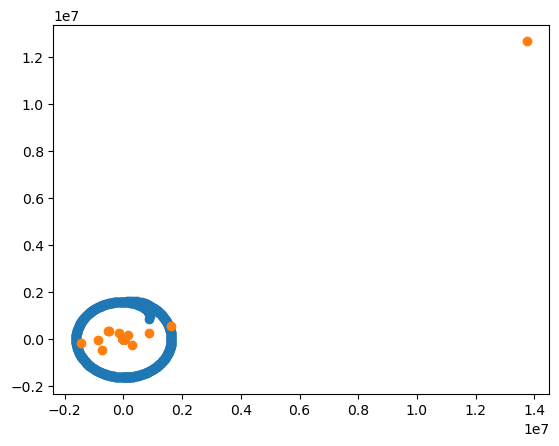

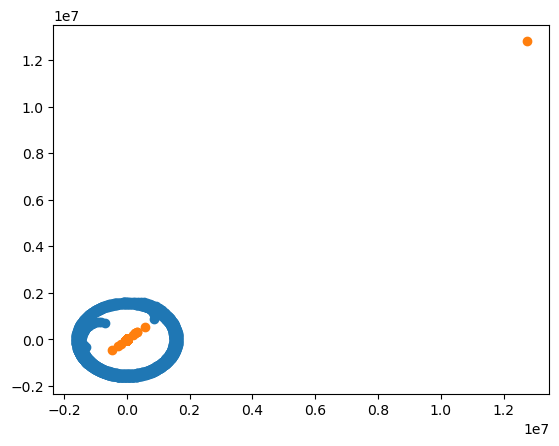

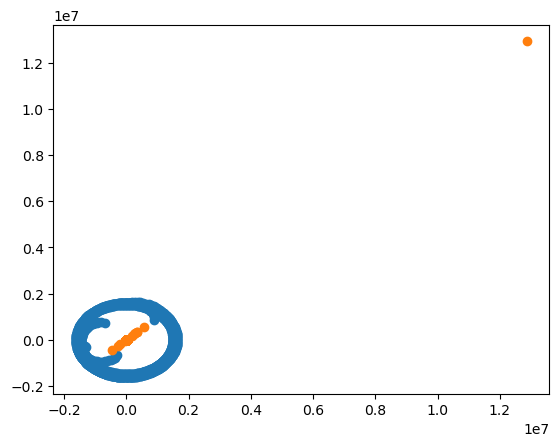

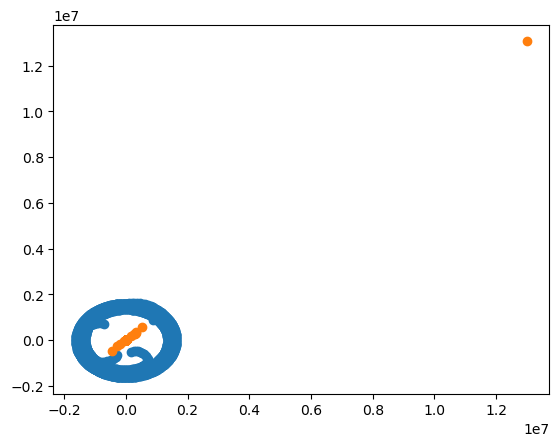

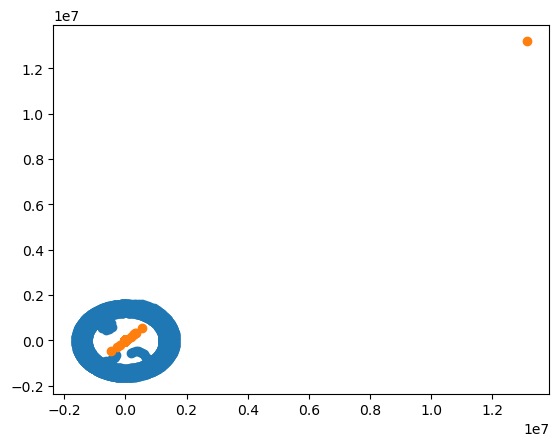

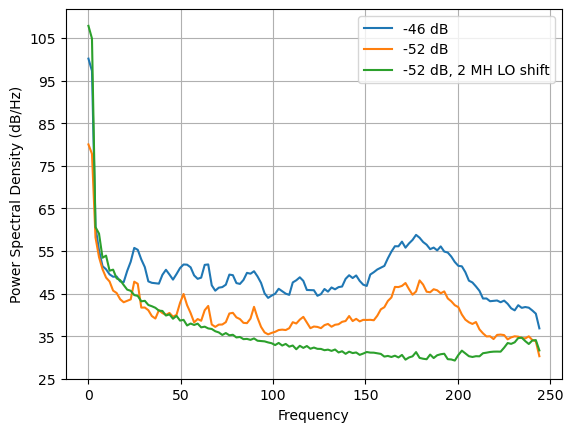

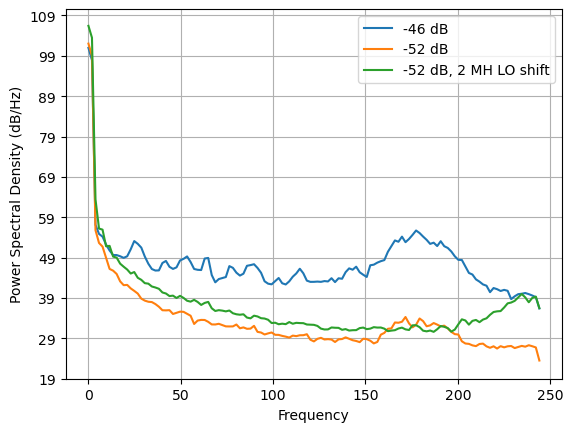

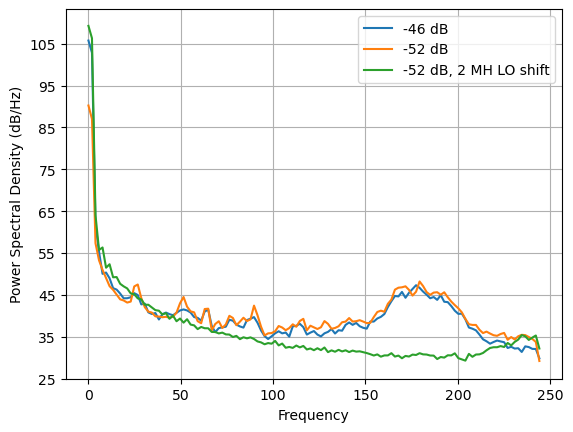

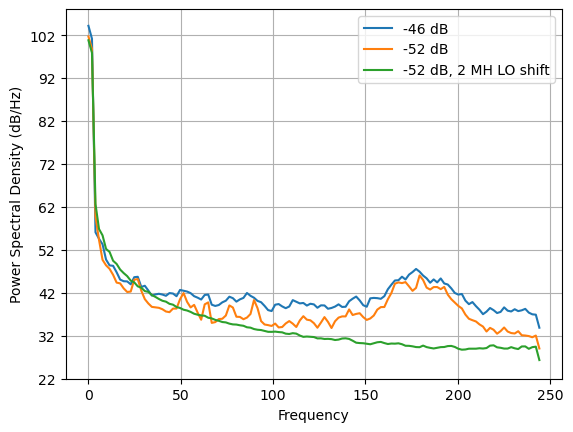

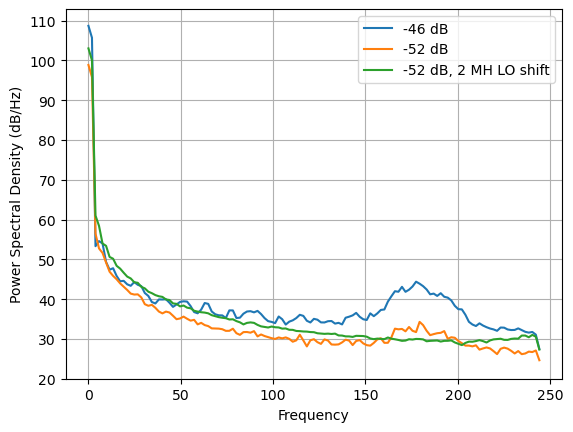

In [69]:
%matplotlib inline
targ_46 = np.load('/home/rfsoc/CCATpHive/tmp/s21_targ_1_1_20221026T103934Z.npy')

targ_52 = np.load('/home/rfsoc/CCATpHive/tmp/s21_targ_1_1_20221026T112351Z.npy')
f_46 = np.load('/home/rfsoc/CCATpHive/tmp/f_res_targ_1_1_20221026T112139Z.npy', allow_pickle = True)
f_52 = np.load('/home/rfsoc/CCATpHive/tmp/f_res_targ_1_1_20221026T104356Z.npy', allow_pickle = True)
s21_46 = np.load('/home/rfsoc/rfsoc_result/Steve/230817/230817_timestream_58mK_30s_-46dBm.npy')
s21_52 = np.load('/home/rfsoc/rfsoc_result/Steve/230817/230817_timestream_58mK_30s_-52dBm.npy')
s21_52_shifted = np.load('/home/rfsoc/rfsoc_result/Steve/230817/230817_timestream_58mK_30s_-52dBm_2MHz.npy')


for i in range(5):
    plt.figure()
    #plt.scatter(np.abs(targ_46[0]), np.angle(np.imag(targ_46[1])))
    #plt.scatter(np.ones(len(s21_46[:, 16+2*i]))*f_46[i], np.angle(s21_46[:, 16+2*i] + 1j*s21_46[:, 16+2*i+1]))
    plt.scatter(np.real(targ_46[1][np.where(np.real(targ_46[0]-f_46[i]) <= 1e6)]), np.imag(targ_46[1][np.where(np.real(targ_46[0]-f_46[i]) <= 1e6)]))
    plt.scatter(s21_46[16+2*i], s21_46[16+2*i+1])
    plt.show()

s21_46 = np.array([s21_46[i]-np.average(s21_46[i]) for i in range(len(s21_46))])
s21_52 = np.array([s21_52[i]-np.average(s21_52[i]) for i in range(len(s21_52))])
s21_52_shifted = np.array([s21_52_shifted[i]-np.average(s21_52_shifted[i]) for i in range(len(s21_52_shifted))])
mag_noise_46 = []
mag_noise_52 = []
mag_noise_52_shifted = []
for i in range(5):
    mag_noise_46.append(np.abs(s21_46[:, 16+i*2], s21_46[:, 16+i*2+1]))
    mag_noise_52.append(np.abs(s21_52[:, 16+i*2], s21_52[:, 16+i*2+1]))
    mag_noise_52_shifted.append(np.abs(s21_52_shifted[:, 16+i*2], s21_52_shifted[:, 16+i*2+1]))
for i in range(5):
    plt.figure()
    plt.psd(mag_noise_46[i], Fs = len(mag_noise_46[i])/30,label = "-46 dB")
    plt.psd(mag_noise_52[i], Fs = len(mag_noise_46[i])/30, label = "-52 dB")
    plt.psd(mag_noise_52_shifted[i], Fs = len(mag_noise_46[i])/30, label = "-52 dB, 2 MH LO shift")
    plt.legend()
    plt.show()

<IPython.core.display.Javascript object>


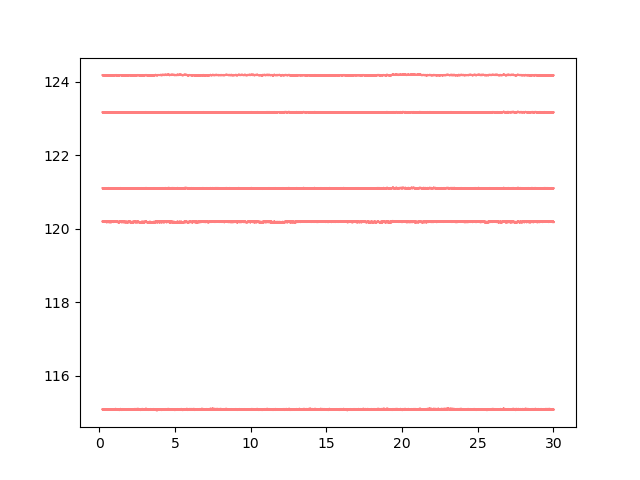

In [15]:
%matplotlib notebook
for i in range(5):
    plt.plot(np.linspace(0,t_sec,N_packet)[100:],
             10*np.log10(p[:, 16+i*2][100:]**2.0+p[:, 17+i*2][100:]**2.0),
             alpha=0.5,color='r', label='0')

<IPython.core.display.Javascript object>


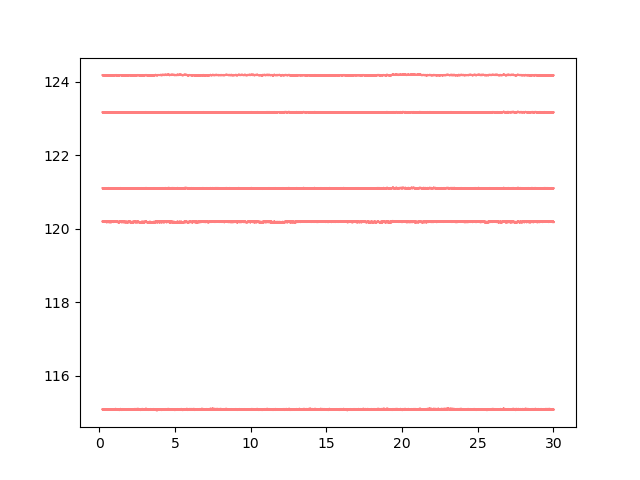

In [16]:
%matplotlib notebook
for i in range(5):
    plt.plot(np.linspace(0,t_sec,N_packet)[100:],
             10*np.log10(p[:, 16+i*2][100:]**2.0+p[:, 17+i*2][100:]**2.0),
             alpha=0.5,color='r', label='0')

<IPython.core.display.Javascript object>


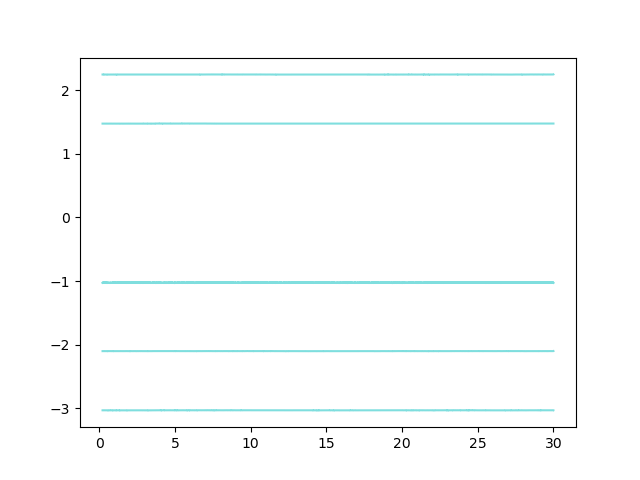

In [17]:
%matplotlib notebook

for i in range(5):
    plt.plot(np.linspace(0,t_sec,N_packet)[100:],np.arctan2(p[:, 17+i*2][100:],p[:, 16+i*2][100:]),
             alpha=0.5,color='c', label='%d'%i)

In [34]:
a = np.load('/home/rfsoc/rfsoc_result/Steve/230713/20230713_timestream_82mK_77K_blackbody_30dBamp.npy')
b = np.load('/home/rfsoc/rfsoc_result/Steve/230713/20230713_timestream_82mK_77K_blackbody_30dBamp_1MHz_LO_shift.npy')
c = np.load('/home/rfsoc/rfsoc_result/Steve/230713/20230713_timestream_82mK_77K_blackbody_30dBamp_LO_shift_back.npy')

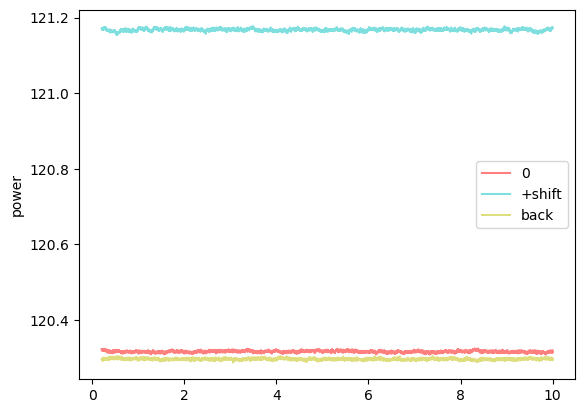

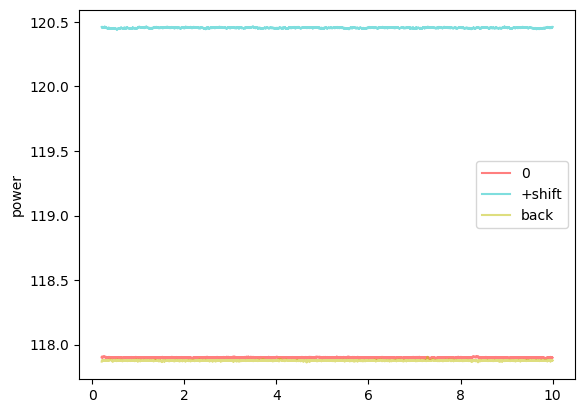

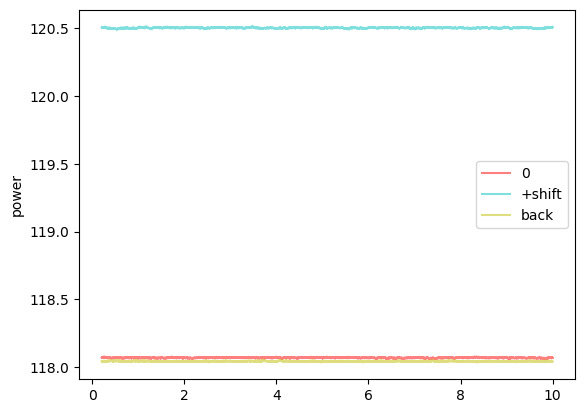

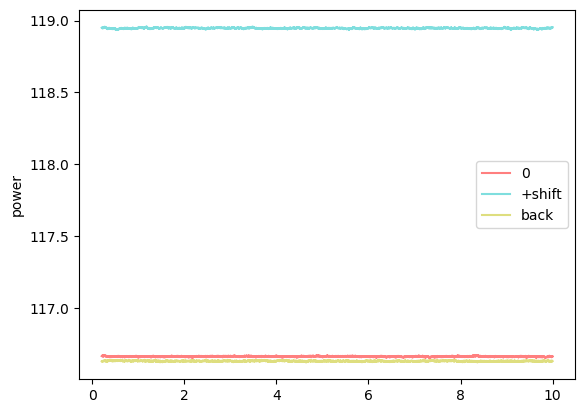

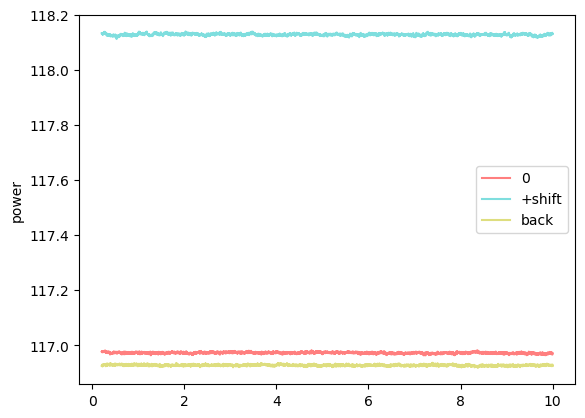

In [35]:
%matplotlib inline
for i in range(5):
    plt.plot(np.linspace(0,t_sec,N_packet)[100:],
             10*np.log10(a[:, 16+i*2][100:]**2.0+a[:, 17+i*2][100:]**2.0),
             alpha=0.5,color='r', label='0')
    plt.plot(np.linspace(0,t_sec,N_packet)[100:],
             10*np.log10(b[:, 16+i*2][100:]**2.0+b[:, 17+i*2][100:]**2.0),
             alpha=0.5,color='c', label='+shift')
    plt.plot(np.linspace(0,t_sec,N_packet)[100:],
             10*np.log10(c[:, 16+i*2][100:]**2.0+c[:, 17+i*2][100:]**2.0),
             alpha=0.5,color='y', label='back')
    
# for i in range(3):
#     plt.plot(np.linspace(0,t_sec,N_packet)[100:],
#              10*np.log10(p_sig[:, 16+i*2][100:]**2.0+p_sig[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p_sig[:, 16+i*2][100:]**2.0+p_sig[:, 17+i*2][100:]**2.0)),
#              alpha=0.3,color='b', label='%d'%i)
    plt.legend()
    plt.ylabel('power')
    plt.show()
    
#plt.plot( np.linspace(0,8,4001),p[:, 16], label="I",alpha=0.4)
#plt.plot(  np.linspace(0,8,4001),p[:, 17], label="Q",alpha=0.4)
#plt.plot( np.linspace(0,8,4001), p[:, 18], label="I_18",alpha=0.4)
#plt.plot(  np.linspace(0,8,4001),p[:, 19], label="Q_19",alpha=0.4)
#plt.plot( np.linspace(0,8,4001),p[:, 16+10*2], label="I_613", alpha=0.4)
#plt.plot(  np.linspace(0,8,4001),p[:, 17+10*2], label="Q_613", alpha=0.4)
#plt.legend()
#plt.savefig('stream_warmamp_on_off.png')

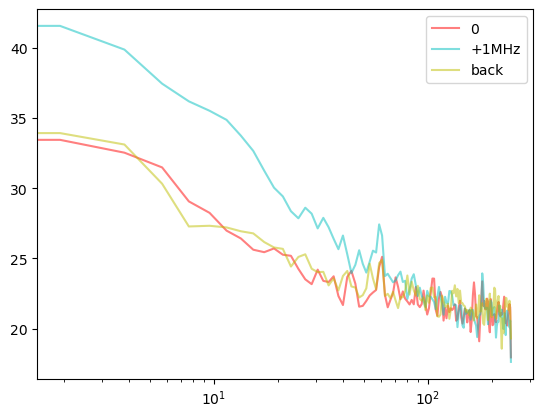

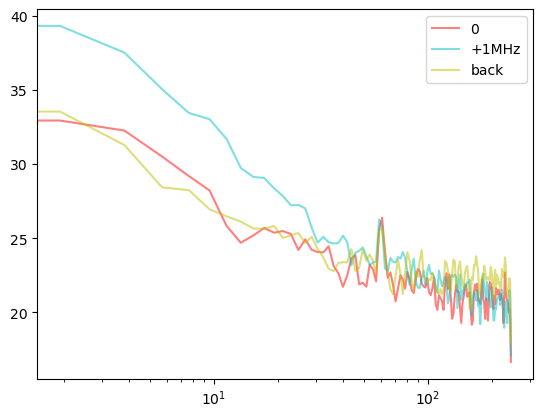

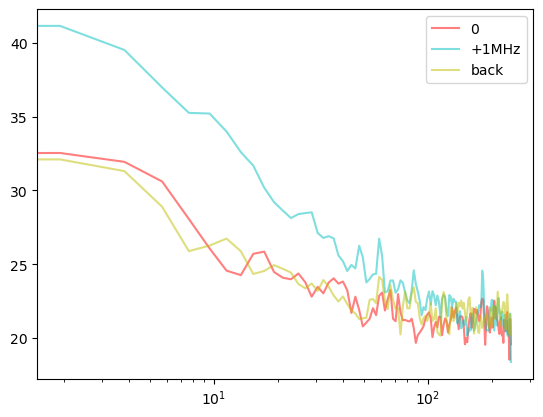

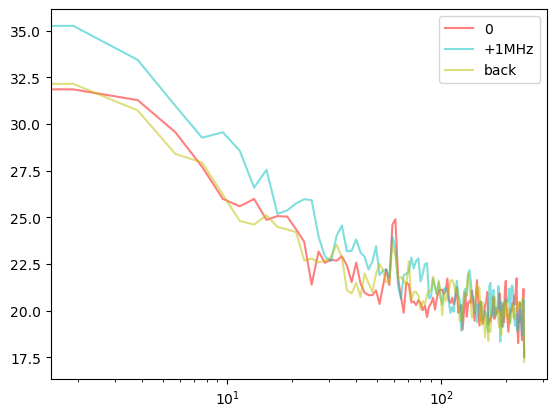

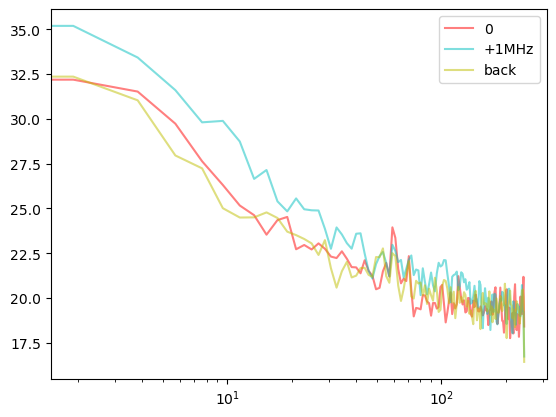

In [37]:
from scipy import signal
%matplotlib inline

for i in range(5):
    f, psd_a = signal.welch(a[:, 16+i*2][100:],fs = 512e6/2**20,nperseg = 256)
    f, psd_b = signal.welch(b[:, 16+i*2][100:],fs = 512e6/2**20,nperseg = 256)
    f, psd_c = signal.welch(c[:, 16+i*2][100:],fs = 512e6/2**20,nperseg = 256)
    plt.semilogx(f,10*np.log10(psd_a),
             alpha=0.5,color='r', label='0')
    plt.semilogx(f,10*np.log10(psd_b),
             alpha=0.5,color='c', label='+1MHz')
    plt.semilogx(f,10*np.log10(psd_c),
             alpha=0.5,color='y', label='back')
    plt.legend()
    plt.show()


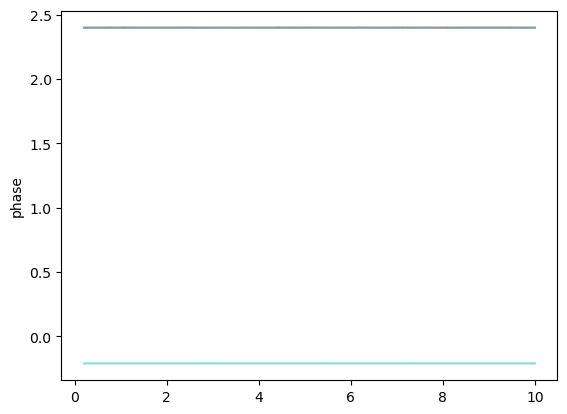

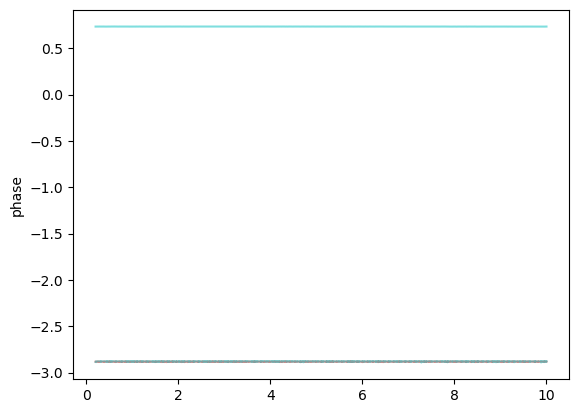

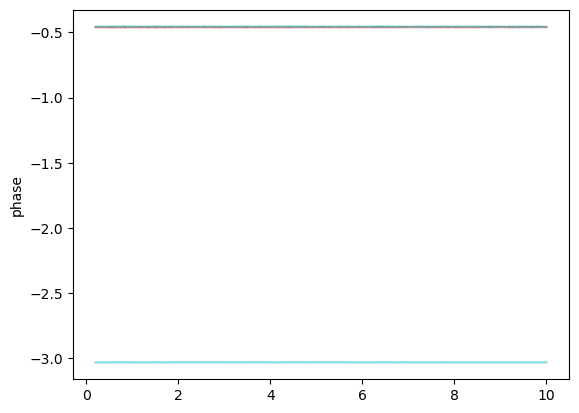

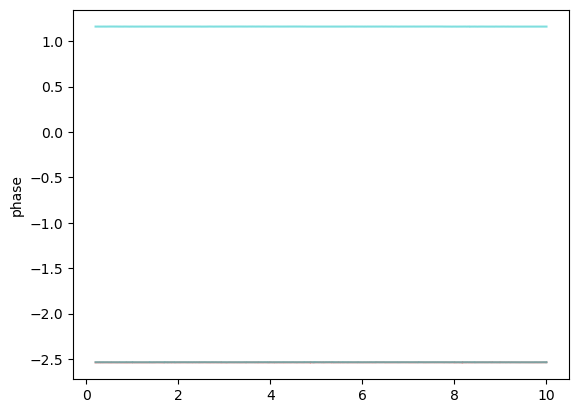

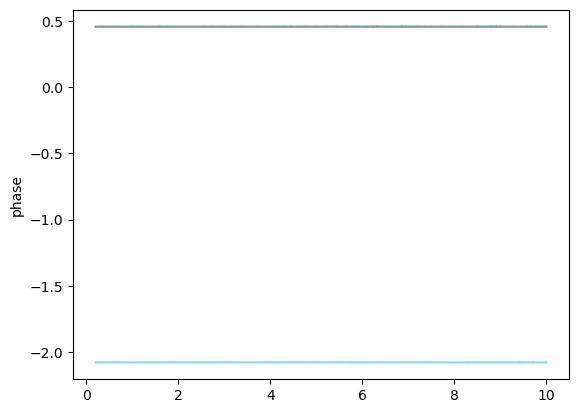

In [41]:
%matplotlib inline
for i in range(5):
    plt.plot(np.linspace(0,t_sec,N_packet)[100:],np.arctan2(a[:, 17+i*2][100:],a[:, 16+i*2][100:]),
             alpha=0.5,color='r', label='%d'%i)
    plt.plot(np.linspace(0,t_sec,N_packet)[100:],np.arctan2(b[:, 17+i*2][100:],b[:, 16+i*2][100:]),
             alpha=0.5,color='c', label='%d'%i)
    plt.plot(np.linspace(0,t_sec,N_packet)[100:],np.arctan2(c[:, 17+i*2][100:],c[:, 16+i*2][100:]),
             alpha=0.5,color='c', label='%d'%i)

    plt.ylabel('phase')
    plt.show()


In [ ]:
%matplotlib notebook
i=1
plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p[:, 16+i*2][100:]**2.0+p[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p[:, 16+i*2][100:]**2.0+p[:, 17+i*2][100:]**2.0)),
             alpha=0.3,color='r', label='det %d,no source'%i)


plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p_sig[:, 16+i*2][100:]**2.0+p_sig[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p_sig[:, 16+i*2][100:]**2.0+p_sig[:, 17+i*2][100:]**2.0)),
             alpha=0.3,color='b', label='det %d 5Hz source'%i)
plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p_sig_wave[:, 16+i*2][100:]**2.0+p_sig_wave[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p_sig_wave[:, 16+i*2][100:]**2.0+p_sig_wave[:, 17+i*2][100:]**2.0)),
             alpha=0.8,color='g', label='det %d,5Hz source amp in box cable shaked'%i)
plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p_sig_wave_out[:, 16+i*2][100:]**2.0+p_sig_wave_out[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p_sig_wave_out[:, 16+i*2][100:]**2.0+p_sig_wave_out[:, 17+i*2][100:]**2.0)),
            alpha=0.3,color='orange', label='det %d,5Hz source amp out of box cable shook'%i )
plt.plot(np.linspace(0,t_sec,512*t_sec)[100:],
             10*np.log10(p_sig_wave_top[:, 16+i*2][100:]**2.0+p_sig_wave_top[:, 17+i*2][100:]**2.0)-np.mean(10*np.log10(p_sig_wave_top[:, 16+i*2][100:]**2.0+p_sig_wave_top[:, 17+i*2][100:]**2.0)),
            alpha=0.3,color='k', label='det %d,5Hz source amp out of cryostat cable shook'%i )
plt.ylabel('power')
plt.legend()

In [ ]:
ang_new=[]
ang_rev=[]
for i in range(14):
    I=p[:, 16+i*2]
    Q=p[:, 17+i*2]
    ang_mean=np.mean(np.arctan2(Q[5000:],I[5000:]))
    #I_prime=I*np.cos(ang_mean)+Q*np.sin(ang_mean)
    #Q_prime=Q*np.cos(ang_mean)-I*np.sin(ang_mean)
    Z=I+1j*Q
    Z_prime=Z*np.exp(-1j*ang_mean)
    I_prime=Z_prime.real
    Q_prime=Z_prime.imag
    Z_reverse=Z*np.exp(1j*ang_mean)
    I_rev=Z_reverse.real
    Q_rev=Z_reverse.imag
    ang_new.append(np.arctan2(Q_prime, I_prime))
    ang_rev.append(np.arctan2(Q_rev, I_rev))
    
ang_new=np.vstack(ang_new)
ang_rev=np.vstack(ang_rev)
    


In [ ]:
for i in range(14):
    plt.plot(np.linspace(0,20,10000)[100:],ang_new[i,:][100:],alpha=0.3,color='r')
    plt.plot(np.linspace(0,20,10000)[100:],ang_rev[i,:][100:],alpha=0.3,color='b')

In [ ]:
pow=p[:, 16+6*2][100:]**2.0+p[:, 17+6*2][100:]**2.0
pow_sel=pow[4000:]
print (np.std(pow_sel))
print (4e10/np.std(pow_sel))

In [ ]:
%matplotlib notebook
for i in range(15):
    if i!=12: continue
    plt.plot(np.linspace(0,16,10000)[100:],np.arctan2(p[:, 16+i*2][100:],p[:, 17+i*2][100:])-np.mean(np.arctan2(p[:, 16+i*2][100:],p[:, 17+i*2][100:])),label='%d'%i)
    
plt.legend()

In [ ]:
phase=np.arctan2(p[:, 16+6*2][100:],p[:, 17+6*2][100:])
phase_sel=phase[4000:]
snr=0.12/np.std(phase_sel)
samp=512e6/2**20 #Hz
snr_thz=snr*samp**0.5
print (snr_thz)
load=15*1.38e-23*60e9
NEP=load/snr_thz
print (NEP)


In [ ]:
phase=np.arctan2(p[:, 16+2*2][100:],p[:, 17+2*2][100:])
phase_sel=phase[4000:]
snr=0.09/np.std(phase_sel)
samp=512e6/2**20 #Hz 
snr_thz=snr*samp**0.5
print (snr_thz)
load=15*1.38e-23*60e9
NEP=load/snr_thz
print (NEP)

In [ ]:
p_ln2=getNpackets_2(8000)

In [ ]:
%matplotlib notebook
for i in range(17):
    if i!=6: continue
    plt.plot(np.linspace(0,16,8000)[100:],10*np.log10(p_ln2[:, 16+i*2][100:]**2.0+p_ln2[:, 17+i*2][100:]**2.0),alpha=0.3, label='%d'%i)
plt.legend()


In [ ]:
%matplotlib notebook
for i in range(15):
    if i!=6: continue
    plt.plot(np.linspace(0,16,8000)[100:],np.arctan2(p_ln2[:, 16+i*2][100:],p_ln2[:, 17+i*2][100:])-np.mean(np.arctan2(p[:, 16+i*2][100:],p[:, 17+i*2][100:])),label='%d'%i)
    
plt.legend()

In [ ]:
pow=p_ln2[:, 16+6*2][100:]**2.0+p_ln2[:, 17+6*2][100:]**2.0
pow_sel=pow[4000:]
print (np.std(pow_sel))

In [ ]:
p_shake=getNpackets_2(4000)

In [ ]:
%matplotlib notebook
for i in range(22):
    plt.plot(np.linspace(0,8,4000)[100:],p_shake[:, 16+i*2][100:]**2.0+p_shake[:, 17+i*2][100:]**2.0, label='%d'%i)
    
plt.legend()

In [ ]:
%matplotlib notebook
for i in range(13):
    plt.plot(np.linspace(0,8,4001)[100:],p_nomag[:, 16+i*2][100:], label='%d'%i)
    
plt.legend()

In [ ]:
%matplotlib notebook
i=5
plt.plot(np.linspace(0,8,4001),p[:, 16+i*2]**2.0+p[:, 17+i*2]**2.0)  

In [ ]:
def get_noise(p,ch):
    pow_ch=p[:, 16+ch*2]**2.0+p[:, 17+ch*2]**2.0
    pow_ch_sel=pow_ch[100:]
    std_ch=np.std(pow_ch_sel)
    print (std_ch)
    return std_ch

In [ ]:
std_coax=get_noise(p,5)
std_off/std_coax

In [ ]:
pow_5=p[:, 16+i*2]**2.0+p[:, 17+i*2]**2.0
pow_5_sel=pow_5[3000:]
std=np.std(pow_5_sel)
print (std)
print (0.5e9/std)

In [ ]:
%matplotlib notebook
plt.plot( np.linspace(0,8,4001)[15:], p[:, 18][15:], label="I_18",alpha=0.4)
plt.plot(  np.linspace(0,8,4001)[15:],p[:, 19][15:], label="Q_19",alpha=0.4)
plt.legend()

In [ ]:
%matplotlib notebook
plt.plot( np.linspace(0,8,4001)[15:], p[:, 18][15:]**2+p[:,19][15:]**2, label="pow",alpha=0.4)
#plt.ylim(3e8,2.13e9)


In [ ]:
data_off=np.load('20230203_packets_wave_LO601_offres.npy')

In [ ]:
i=5
pow_5_off=data_off[:, 16+i*2]**2.0+data_off[:, 17+i*2]**2.0
pow_5_sel_off=pow_5_off[15:]
std_off=np.std(pow_5_sel_off)
print (std/std_off)

In [ ]:
np.save('20230203_packets_wave_LO600_onres.npy',p)

In [ ]:
#hand width 6cm, window is 25cm in diameter
25*6/(25**2*0.25*np.pi)
#assuming a 273+37=310K, 15k delta T
peak=3.5e8
baseline=3.1e8
var=0.05e8/2**0.5
snr=(peak-baseline)/var
BW=512e6/2**20 #in Hz
snr_hz=snr*np.sqrt(BW)
dp=1*1.38e-23*50e9*0.1*0.7*0.8#if 10.5icm, resulting 50GHz BW
NEP=dp/snr
NEP
#250-310GHz 
dp=293*1.38e-23*50e9*0.1*0.7*0.8#if 10.5icm 



In [ ]:
file='tmp/freqs_vna_20221011T225216Z.npy'
freq_data=np.load(file)

In [ ]:
#plt.plot(p[:, 0]**2.0+p[:, 1]**2.0, label='ch0001')
#plt.plot(p[:, 1998]**2.0+p[:, 1999]**2.0,label='ch1000')
plt.plot(p[:, 16]**2.0+p[:, 17]**2.0, label='ch0001')
plt.plot(p[:, 2014]**2.0+p[:, 2015]**2.0,label='ch1000')
plt.legend()
#plt.yscale('log')

In [ ]:
freq_data+=1e9

In [ ]:
for i in range(1000):
    plt.scatter(freq_data[i],20*np.log10((p[10,i*2+16]**2+p[10,i*2+17]**2)**0.5), alpha=0.1, color='b')
#freq_data

In [ ]:
6.18457736e+08-